In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models

#####################################################################################################

import utils 
importlib.reload(utils) #reload the utils module to get the latest changes

####################################################################################################

from sklearn.metrics import f1_score
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
from tqdm import tqdm
from collections import OrderedDict

####################################################################################################

from utils import (plot_class_distribution, show_class_distribution, create_spatial_train_test_val_split , 
                   display_random_samples , find_and_remove_black_images , fix_images, check_duplicates, 
                   remove_duplicates, show_img_size_and_channels,get_class_weights, evaluate_test_set, get_mean_and_std,
                   plot_pytorch_history , set_seed, visualize_random_gradcam)
from data_fetch import download_dataset


# Globals

In [2]:
# PATHS AND SEED --!-- DO NOT EDIT --!--
ROOT_DIR = Path('./data/')
DATA_DIR = ROOT_DIR / 'data'
TEST_DIR = ROOT_DIR / 'test/'
TRAIN_DIR = ROOT_DIR / 'train/'
VAL_DIR = ROOT_DIR / 'val/'
SEED = 42

# HYPERPARAMETERS
BATCH_SIZE = 64
IMG_SIZE = (128, 128)
LEARNING_RATE = 0.0001
NUM_EPOCHS = 40

In [3]:
set_seed(SEED)

Graine aléatoire fixée à 42 🌱


# Data Fetching & Initial Cleaning

In [4]:
download_dataset('harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset', ROOT_DIR)

Dataset URL: https://www.kaggle.com/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset
Done! Dataset location: /home/andrealoy/Documents/repos/sentinel-1-oil-detection/data
Folders found: ['metadata', 'data']


**Deleting the Samples folder as we will not use it**

In [5]:
!rm -rf {DATA_DIR / 'Samples'}
print("Removed 'Samples' directory from the dataset")

Removed 'Samples' directory from the dataset


In [6]:
plot_class_distribution(DATA_DIR)

In [7]:
show_class_distribution(DATA_DIR)

Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 3725
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1905


In [8]:
fix_images(DATA_DIR)

Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/422_10000_6200_img_8UXGVkszCbidTR49_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2857_9000_11200_img_NgkRiqvlSMUKRxSO_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_CFAY073B8sznfZJG_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2_400_0_img_0t9JBHeOeBHgaLmJ_JAV_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/2690_2600_9400_img_8jmWSIh9LhIh4p4e_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/15_600_600_img_yypoVwlHZPchMcLa_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/1064_9200_7400_img_xCVKEyUQBMP2ef8r_GBR_cls_0.jpg of type: jpeg
Accepted file: data/data/S1SAR_UnBalanced_400by400_Class_0/0/460_5400_3000_img_lHgjbs0x2eQq1CKp_GBR_cls_0.jpg of type: jpeg
Accepted file: data/

In [9]:
show_class_distribution(DATA_DIR)

Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 3725
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 1905


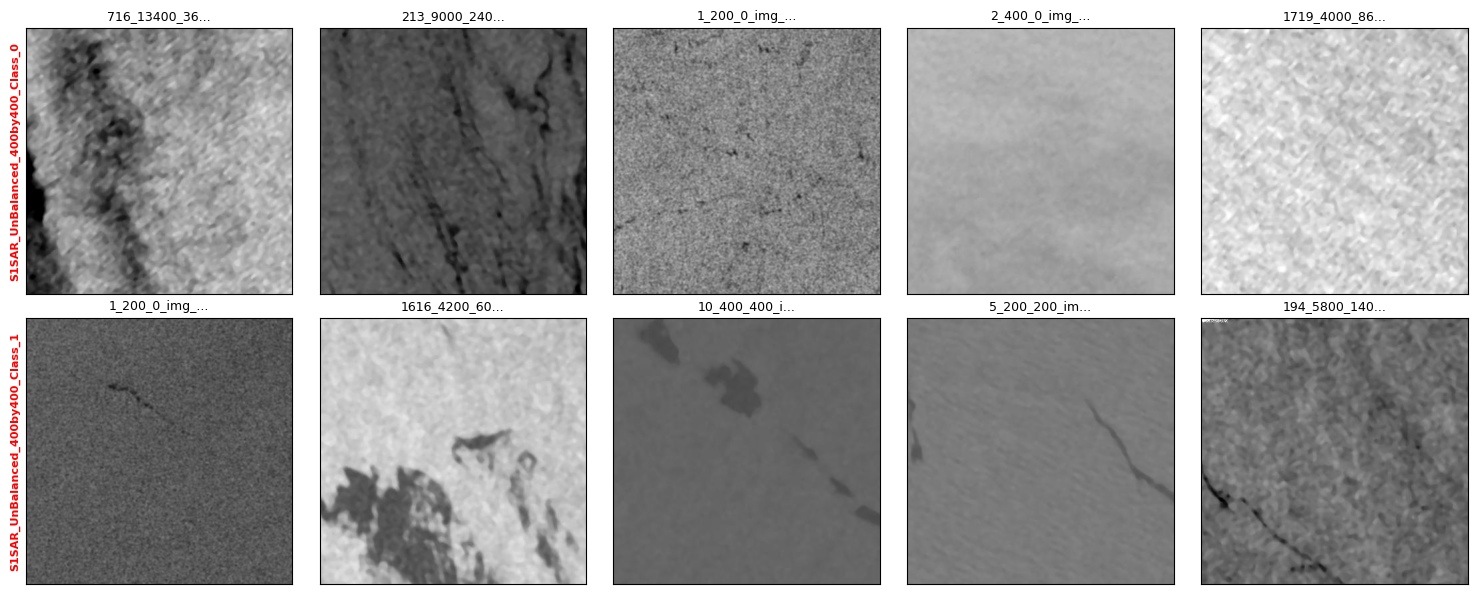

In [10]:
display_random_samples(DATA_DIR)

In [11]:
show_img_size_and_channels("data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_0CugGbeejr96zxqr_SFr_cls_0.jpg")

Image: data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_0CugGbeejr96zxqr_SFr_cls_0.jpg - Size: (400, 400) (Width x Height) - Channels: 3


In [12]:
find_and_remove_black_images(DATA_DIR, threshold=1 , delete=True)

🧹 Nombre d'images noires détectées : 11
🗑️ Toutes les images noires ont été supprimées !


[PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_5kYRxJroyooz6Wlc_SFr_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_8YWuJFw4wUT6HnRg_JAV_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_VKcoB3XqXja85g1F_JAV_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_yfkHG0CsGwuVkVnj_JAV_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_WdQxBNQ9jNtSXgwk_JAV_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/3_600_0_img_TOSro3JnVPiR2idV_BOR_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_SCoVQ72iCMzSlCo5_CHS_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/3_600_0_img_6WOLlxJ2OAB29QpL_SFr_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_B5RycPetmGHFpLmr_BOR_cls_0.jpg'),
 PosixPath('data/data/S1SAR_UnBalanced_400by400_Class_0/0/0_0_0_img_PNhKlvnLE5

In [13]:
create_spatial_train_test_val_split(
    DATA_DIR,
    output_dir=ROOT_DIR,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    seed=SEED,
 )

🌍 Démarrage du split spatial (Group-based)...
🗺️ Nombre total de régions uniques trouvées : 26
Exemples de régions : ['MLA', 'JAP', 'GGu', 'VEN', 'PHI']
📊 Répartition des régions -> Train: 20 | Val: 3 | Test: 3
✅ Split spatial terminé ! Données étanches sauvegardées dans : data


In [14]:
check_duplicates(TRAIN_DIR)

⚠️ 32 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 0_0_0_img_UGpmBGc3xT5Ilril_GGu_cls_1.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_rVRa9Qez2AYh3poi_JAV_cls_1.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_UGpmBGc3xT5Ilril_GGu_cls_1.jpg
 - Fichier : 9_200_400_img_SEgVUvivlWqcqq1V_GGu_cls_1.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_1/9_200_400_img_3ec9w19m4ROr02CA_JAV_cls_1.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_1/9_200_400_img_SEgVUvivlWqcqq1V_GGu_cls_1.jpg
 - Fichier : 0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
 - Fichier : 1_200_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_1/1_200_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_1/1_200

[('0_0_0_img_UGpmBGc3xT5Ilril_GGu_cls_1.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_rVRa9Qez2AYh3poi_JAV_cls_1.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_UGpmBGc3xT5Ilril_GGu_cls_1.jpg'),
 ('9_200_400_img_SEgVUvivlWqcqq1V_GGu_cls_1.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_1/9_200_400_img_3ec9w19m4ROr02CA_JAV_cls_1.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_1/9_200_400_img_SEgVUvivlWqcqq1V_GGu_cls_1.jpg'),
 ('0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg'),
 ('1_200_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_1/1_200_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg',
  'data/train/S1SAR_UnBalanced_400by400_Class_1/1_200_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg'),
 ('1_200_0_img_BnQrY5XBUEExFNYk_GGu_cls_1.jpg',
  'data/train/S1SA

In [15]:
check_duplicates(TEST_DIR)

✅ Aucun doublon de contenu trouvé dans ou entre les dossiers.


[]

In [16]:
check_duplicates(VAL_DIR)

⚠️ 59 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
   1. data/val/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg
   2. data/val/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg
 - Fichier : 535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg
   1. data/val/S1SAR_UnBalanced_400by400_Class_0/535_1800_2600_img_YTAQHQ6Ub5AO2wEx_SIN_cls_0.jpg
   2. data/val/S1SAR_UnBalanced_400by400_Class_0/535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg
 - Fichier : 2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
   1. data/val/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg
   2. data/val/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg
 - Fichier : 1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg
   1. data/val/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN

[('2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_EppU8Z5MCiREy7AA_GBR_cls_0.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_0/2417_1800_8200_img_oPx7qPNx24aVeH4E_GBR_cls_0.jpg'),
 ('535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_0/535_1800_2600_img_YTAQHQ6Ub5AO2wEx_SIN_cls_0.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_0/535_1800_2600_img_EpKy0bMLMBTw9AGy_SIN_cls_0.jpg'),
 ('2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_l7912hDB89MxQhzN_GBR_cls_0.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_0/2905_8000_10000_img_Uz3OanLI6cQJ14Fc_GBR_cls_0.jpg'),
 ('1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_P81b6DktZJCbmOmO_SIN_cls_0.jpg',
  'data/val/S1SAR_UnBalanced_400by400_Class_0/1995_600_7000_img_87nd99XlTVXvHTT2_SIN_cls_0.jp

In [17]:
remove_duplicates(TRAIN_DIR,TEST_DIR,VAL_DIR)

Recherche des doublons à supprimer...
⚠️ 91 doublons trouvés (contenu identique) !
Exemples de doublons :
 - Fichier : 0_0_0_img_UGpmBGc3xT5Ilril_GGu_cls_1.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_rVRa9Qez2AYh3poi_JAV_cls_1.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_UGpmBGc3xT5Ilril_GGu_cls_1.jpg
 - Fichier : 9_200_400_img_SEgVUvivlWqcqq1V_GGu_cls_1.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_1/9_200_400_img_3ec9w19m4ROr02CA_JAV_cls_1.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_1/9_200_400_img_SEgVUvivlWqcqq1V_GGu_cls_1.jpg
 - Fichier : 0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
   2. data/train/S1SAR_UnBalanced_400by400_Class_1/0_0_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
 - Fichier : 1_200_0_img_oAo0xyFOE8fJIeuF_GGu_cls_1.jpg
   1. data/train/S1SAR_UnBalanced_400by400_Class_1/1_200_0_img_0sH5cTJBApOQUHa0_GGu_cls_1.jpg
   2. data/train/S

91

In [18]:
print("="*50)
print("DISTRIBUTION FOR TRAIN DIR:")
show_class_distribution(TRAIN_DIR)
print("="*50)


print("="*50)
print("DISTRIBUTION FOR TEST DIR:")
show_class_distribution(TEST_DIR)
print("="*50)

print("="*50)
print("DISTRIBUTION FOR VAL DIR:")
show_class_distribution(VAL_DIR)
print("="*50)


DISTRIBUTION FOR TRAIN DIR:
Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 565
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 801
DISTRIBUTION FOR TEST DIR:
Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 132
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 63
DISTRIBUTION FOR VAL DIR:
Class: S1SAR_UnBalanced_400by400_Class_0 - Number of samples: 2988
Class: S1SAR_UnBalanced_400by400_Class_1 - Number of samples: 979


In [19]:
temp_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
temp_dataset = datasets.ImageFolder(TRAIN_DIR, transform=temp_transforms)
temp_loader = DataLoader(temp_dataset, batch_size=BATCH_SIZE)

mean, std = get_mean_and_std(temp_loader)
print(f"Image Mean : {mean.item():.4f}")
print(f"Image Std : {std.item():.4f}")

Image Mean : 0.4430
Image Std : 0.0490


# Simple CNN

In [20]:
MEAN = [0.5195]
STD = [0.0912]

# Define data transformations
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # 1 channel for grayscale images
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5), 
    transforms.RandomRotation(15), 
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD) # ImageNet mean and std for grayscale images
])
test_val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Create datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=test_val_transforms)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_val_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Compute class weights for handling class imbalance
weights: torch.Tensor = get_class_weights(train_dataset)

In [21]:
weights

tensor([1.2088, 0.8527])

In [22]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, img_size=(128, 128)):
        super(SimpleCNN, self).__init__()
        
        # On remplace la liste simple par un OrderedDict
        self.conv_section = nn.Sequential(OrderedDict([
            # Block 1
            ('conv1', nn.Conv2d(1, 16, kernel_size=5, padding=2)),
            ('bn1', nn.BatchNorm2d(16)),
            ('relu1', nn.ReLU()),
            ('pool1', nn.MaxPool2d(2, 2)),
            
            # Block 2
            ('conv2', nn.Conv2d(16, 32, kernel_size=3, padding=1)),
            ('bn2', nn.BatchNorm2d(32)),
            ('relu2', nn.ReLU()),
            ('pool2', nn.MaxPool2d(2, 2)),

            # Block 3
            ('conv3', nn.Conv2d(32, 64, kernel_size=3, padding=1)),
            ('bn3', nn.BatchNorm2d(64)),
            ('relu3', nn.ReLU()),
            ('pool3', nn.MaxPool2d(2, 2)),  

            # Block 4
            ('conv4', nn.Conv2d(64, 128, kernel_size=3, padding=1)),
            ('bn4', nn.BatchNorm2d(128)),
            ('relu4', nn.ReLU()),
            ('pool4', nn.MaxPool2d(2, 2))
        ]))
        
        self.flatten_size = 128 * (img_size[0] // 16) * (img_size[1] // 16)
        
        # On peut faire pareil pour le classifieur
        self.classifier = nn.Sequential(OrderedDict([
            ('flatten', nn.Flatten()),
            ('fc1', nn.Linear(self.flatten_size, 128)),
            ('relu_fc', nn.ReLU()),
            ('dropout', nn.Dropout(0.5)),
            ('fc2', nn.Linear(128, 2))
        ]))

    def forward(self, x):
        x = self.conv_section(x) 
        x = self.classifier(x)
        return x

In [23]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, weights=None, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    
    # Config
    criterion = nn.CrossEntropyLoss(weight=weights.to(device) if weights is not None else None)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
    
    # History initialization
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train() 
        running_train_loss = 0.0
        pbar = tqdm(train_loader, unit="batch", desc=f"Epoch {epoch+1}/{epochs}")
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            pbar.set_postfix(loss=loss.item())
        
        avg_train_loss = running_train_loss / len(train_loader)
        
        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        val_preds = []
        val_targets = []
        
        with torch.no_grad(): 
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels) 
                running_val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
        
        avg_val_loss = running_val_loss / len(val_loader)
        score_f1 = f1_score(val_targets, val_preds)
        
        # Save into history for plotting later
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(score_f1)
        
        print(f"Epoch {epoch+1} summary:")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {score_f1:.4f}")
        print("-" * 30)
        
        # Scheduler checks if the validation loss has plateaued to reduce the learning rate if needed
        scheduler.step(avg_val_loss)

    return history

**TRAINING**

In [24]:
baseline = SimpleCNN(img_size=IMG_SIZE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Fit
history = train_model(baseline, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, weights, device=device)

Epoch 1/40: 100%|██████████| 22/22 [00:01<00:00, 15.03batch/s, loss=0.596]


Epoch 1 summary:
Train Loss: 0.6007 | Val Loss: 0.7395 | Val F1: 0.4020
------------------------------


Epoch 2/40: 100%|██████████| 22/22 [00:01<00:00, 18.15batch/s, loss=0.575]


Epoch 2 summary:
Train Loss: 0.5749 | Val Loss: 0.6480 | Val F1: 0.3588
------------------------------


Epoch 3/40: 100%|██████████| 22/22 [00:01<00:00, 17.92batch/s, loss=0.41] 


...

Epoch 38 summary:
Train Loss: 0.4976 | Val Loss: 0.6304 | Val F1: 0.3851
------------------------------


Epoch 39/40: 100%|██████████| 22/22 [00:01<00:00, 18.40batch/s, loss=0.547]


Epoch 39 summary:
Train Loss: 0.5039 | Val Loss: 0.6302 | Val F1: 0.3823
------------------------------


Epoch 40/40: 100%|██████████| 22/22 [00:01<00:00, 18.34batch/s, loss=0.555]


Epoch 40 summary:
Train Loss: 0.4979 | Val Loss: 0.6305 | Val F1: 0.3852
------------------------------


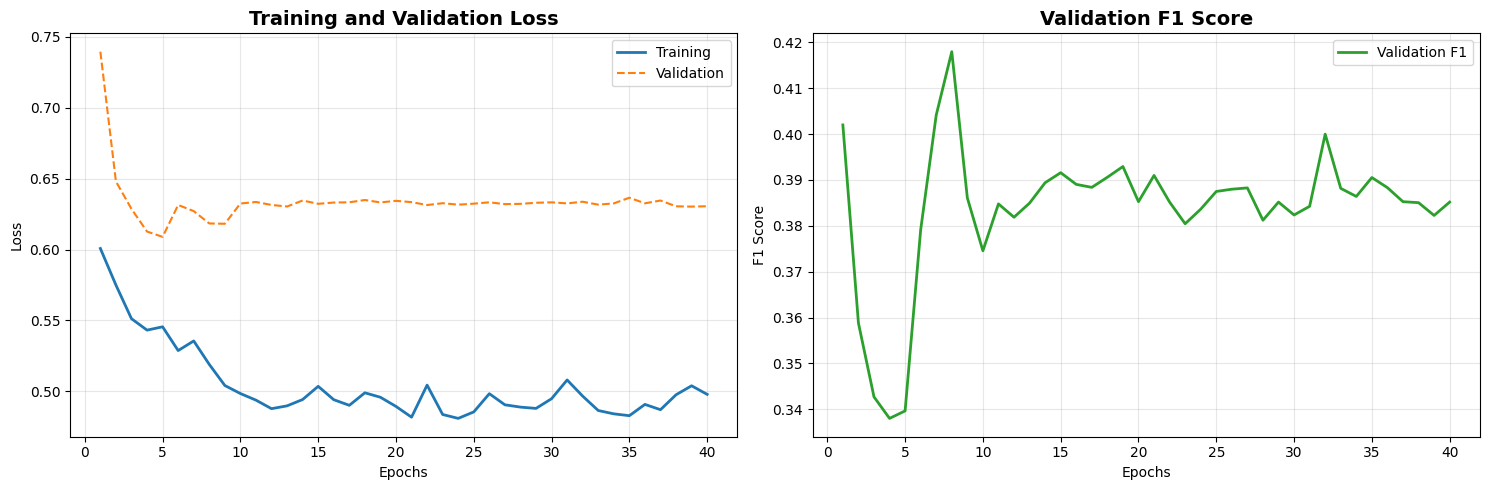

In [25]:
plot_pytorch_history(history)


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Class 0       0.81      0.97      0.88       132
     Class 1       0.89      0.51      0.65        63

    accuracy                           0.82       195
   macro avg       0.85      0.74      0.76       195
weighted avg       0.83      0.82      0.80       195



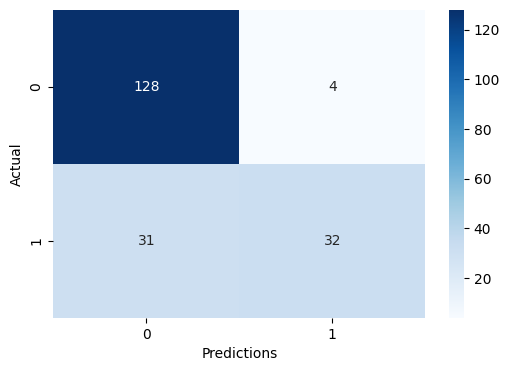

In [26]:
evaluate_test_set(baseline, test_loader, device)

# RESNET18 TEST

In [27]:
resnet = models.resnet18(weights='DEFAULT')
resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False) # First layer modification to accept 1 channel instead of 3 for grayscale images
resnet.fc = nn.Linear(resnet.fc.in_features, 2) # Final layer modification for binary classification
resnet.to(device)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [28]:
history_resnet = train_model(resnet, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, weights, device=device)

Epoch 1/40: 100%|██████████| 22/22 [00:01<00:00, 15.42batch/s, loss=0.458]


Epoch 1 summary:
Train Loss: 0.5492 | Val Loss: 0.6992 | Val F1: 0.4923
------------------------------


Epoch 2/40: 100%|██████████| 22/22 [00:01<00:00, 15.79batch/s, loss=0.314]


Epoch 2 summary:
Train Loss: 0.3694 | Val Loss: 0.5729 | Val F1: 0.5758
------------------------------


Epoch 3/40: 100%|██████████| 22/22 [00:01<00:00, 15.94batch/s, loss=0.262]


...

Epoch 38 summary:
Train Loss: 0.0813 | Val Loss: 0.4631 | Val F1: 0.7690
------------------------------


Epoch 39/40: 100%|██████████| 22/22 [00:01<00:00, 15.62batch/s, loss=0.225] 


Epoch 39 summary:
Train Loss: 0.0921 | Val Loss: 0.4752 | Val F1: 0.7689
------------------------------


Epoch 40/40: 100%|██████████| 22/22 [00:01<00:00, 15.75batch/s, loss=0.198] 


Epoch 40 summary:
Train Loss: 0.0898 | Val Loss: 0.4652 | Val F1: 0.7681
------------------------------


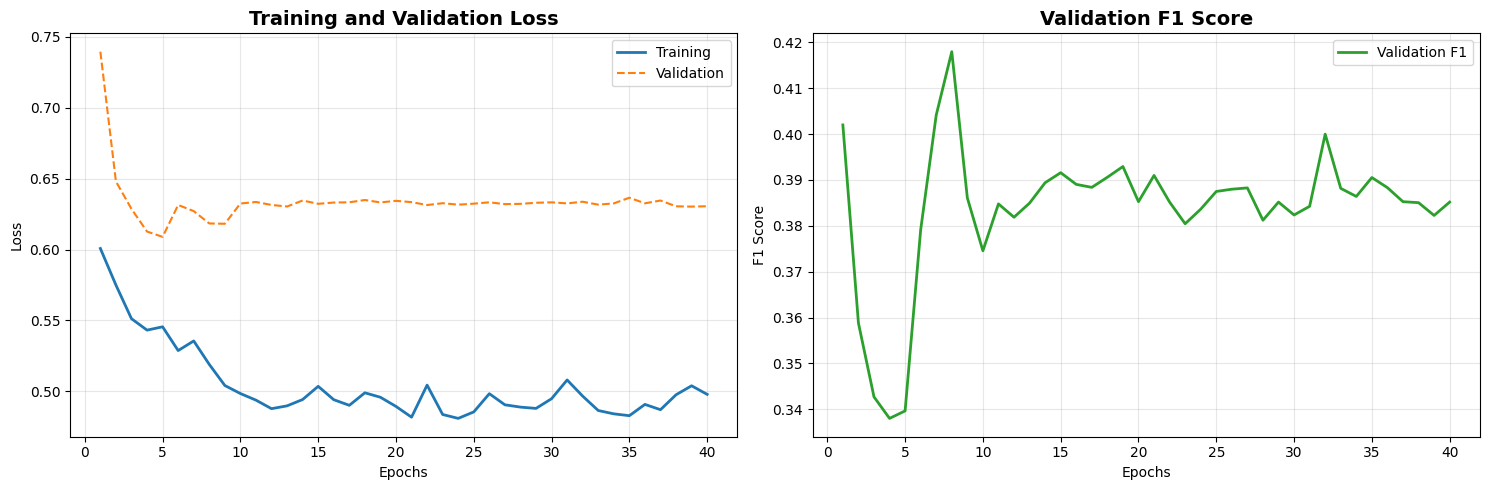

In [29]:
plot_pytorch_history(history)


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Class 0       0.95      0.95      0.95       132
     Class 1       0.90      0.90      0.90        63

    accuracy                           0.94       195
   macro avg       0.93      0.93      0.93       195
weighted avg       0.94      0.94      0.94       195



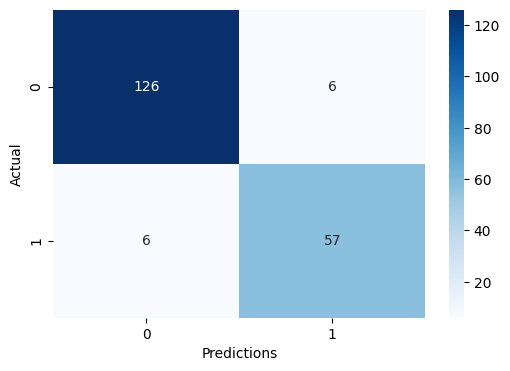

In [30]:
evaluate_test_set(resnet, test_loader, device)

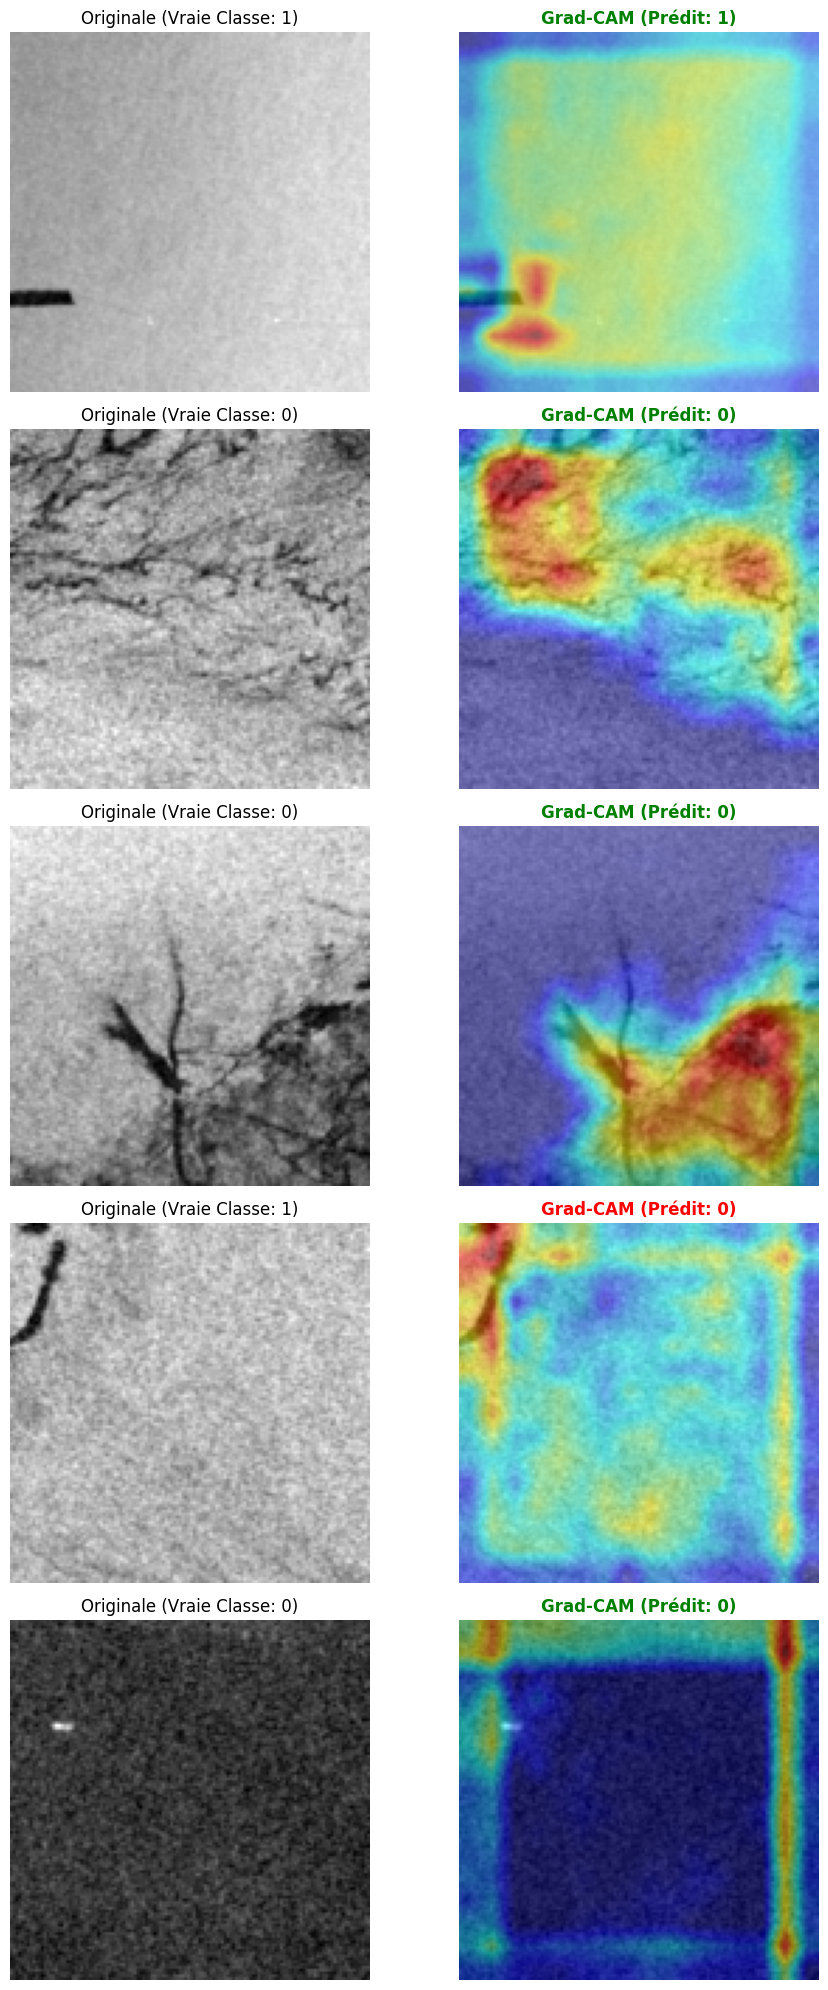

In [31]:
# Affiche 5 images au hasard pour le ResNet
visualize_random_gradcam(
    model=baseline, 
    target_layer=baseline.conv_section.conv4, # La dernière couche convolutive de SimpleCNN
    dataset=test_dataset, 
    device=device, 
    num_images=5
)

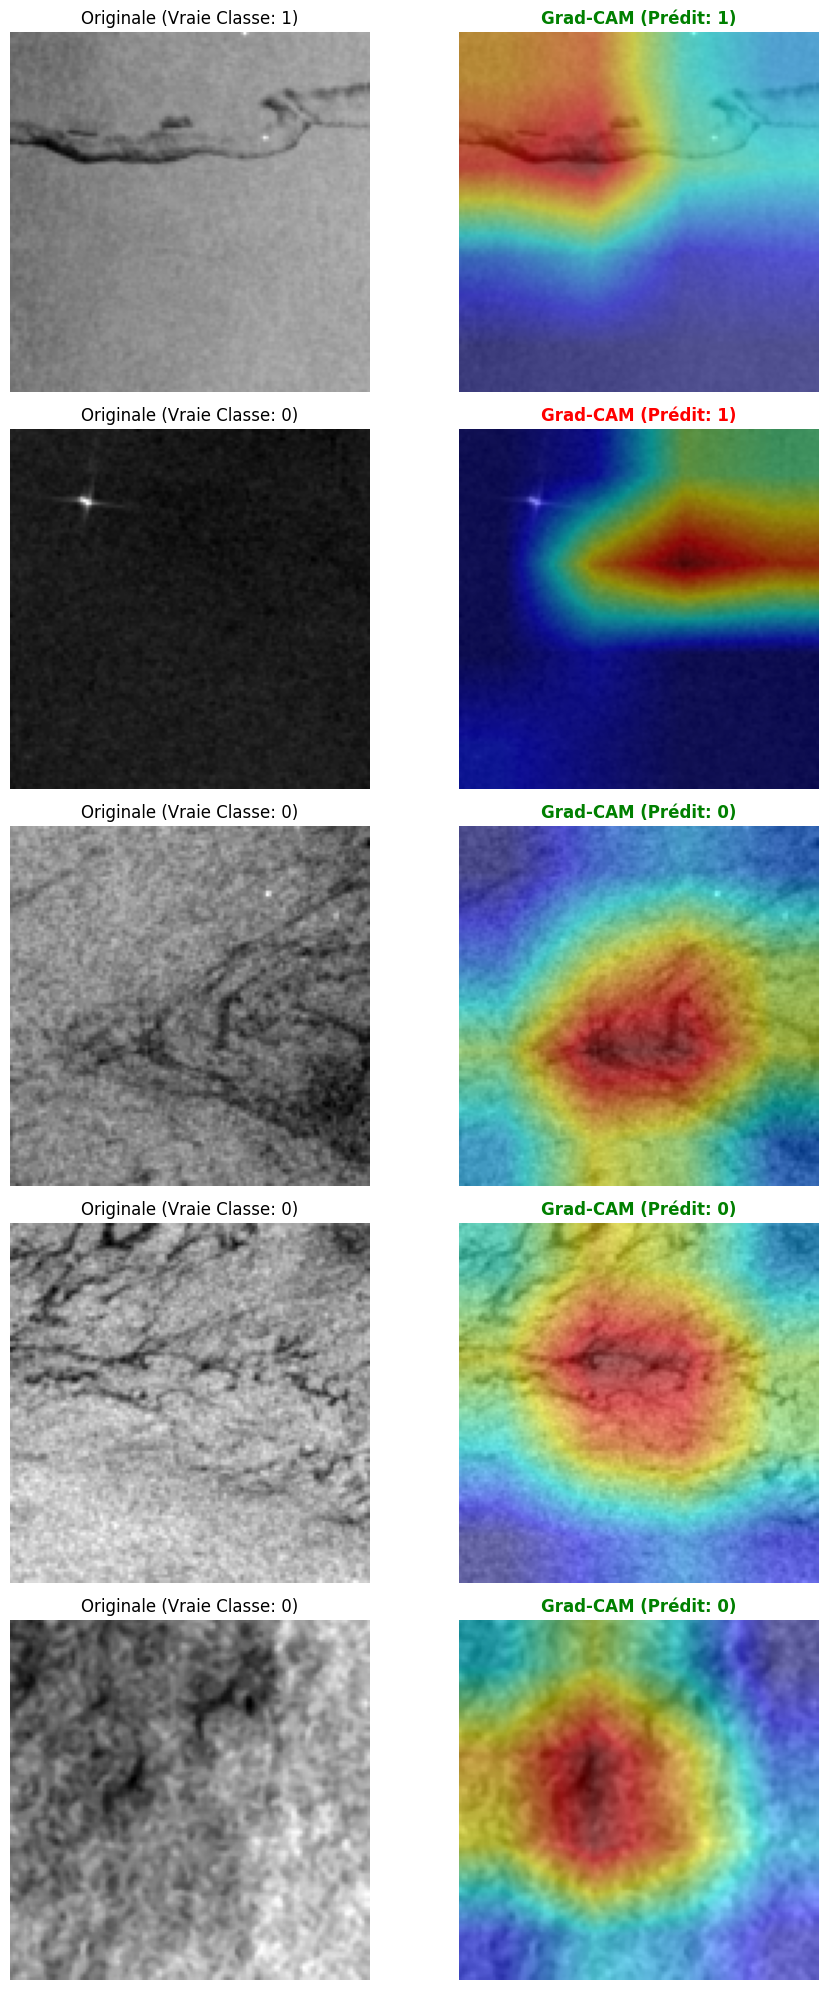

In [32]:
# Affiche 5 images au hasard pour le ResNet
visualize_random_gradcam(
    model=resnet, 
    target_layer=resnet.layer4[-1], # La dernière couche convolutive de ResNet
    dataset=test_dataset, 
    device=device, 
    num_images=5
)